# CIFAR-10 ResNet Watermarked Training

This notebook contains the training code directly, so Colab runs it without launching a separate Python script.

In [1]:
# Optional: mount Google Drive if your repo lives there.
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
from pathlib import Path
import subprocess

repo_dir = Path('/content/DVBW')
if not repo_dir.exists():
    subprocess.run(['git', 'clone', 'https://github.com/THUYimingLi/DVBW.git', str(repo_dir)], check=True)
    print(f'Cloned repository to {repo_dir}')
else:
    print(f'Repository already present at {repo_dir}')

Cloned repository to /content/DVBW


In [3]:
from pathlib import Path
import os

candidates = [Path.cwd(), Path.cwd() / 'CIFAR', Path('/content/DVBW/CIFAR'), Path('/content/drive/MyDrive/DVBW/CIFAR')]
WORKDIR = next((path for path in candidates if (path / 'model.py').exists()), None)
if WORKDIR is None:
    raise FileNotFoundError('Could not find the CIFAR folder. Open this notebook from the repo, or set WORKDIR manually.')
os.chdir(WORKDIR)
print(f'Working directory: {WORKDIR}')

Working directory: /content/DVBW/CIFAR


In [4]:
%pip install -q matplotlib pillow numpy

In [ ]:
from types import SimpleNamespace

args = SimpleNamespace(
    workers=2,
    epochs=200,
    start_epoch=0,
    train_batch=128,
    test_batch=128,
    lr=0.1,
    drop=0,
    schedule=[150, 180],
    gamma=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    checkpoint='./checkpoint/infected/resnet_sinusoid_colab',
    resume='',
    manualSeed=666,
    evaluate=False,
    gpu_id='0',
    poison_rate=0.1,
    watermark_type='sinusoid',  # 'image' or 'sinusoid'
    trigger='./triggers/Trigger_cross.png',
    alpha='./triggers/Alpha_cross.png',
    sinusoid_frequency=4.0,
    sinusoid_alpha=0.05,
    y_target=0,
)
args


namespace(workers=2,
          epochs=200,
          start_epoch=0,
          train_batch=128,
          test_batch=128,
          lr=0.1,
          drop=0,
          schedule=[150, 180],
          gamma=0.1,
          momentum=0.9,
          weight_decay=0.0005,
          checkpoint='./checkpoint/infected/resnet_sinusoid_colab',
          resume='',
          manualSeed=666,
          evaluate=False,
          gpu_id='0',
          poison_rate=0.1,
          watermark_type='sinusoid',
          trigger='./triggers/Trigger_cross.png',
          alpha='./triggers/Alpha_cross.png',
          sinusoid_frequency=4.0,
          sinusoid_alpha=0.05,
          y_target=0)

In [6]:
import os
import random
import shutil

import numpy as np
import torch
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from PIL import Image
from tqdm import tqdm
from torchvision import utils as vutils

from model import *
from utils import Logger, AverageMeter, accuracy, mkdir_p, savefig


class ImageTriggerAppending(object):
    """Blend an image trigger into a PIL image."""

    def __init__(self, trigger, alpha):
        self.trigger = np.array(trigger.clone().detach().permute(1, 2, 0) * 255)
        self.alpha = np.array(alpha.clone().detach().permute(1, 2, 0))

    def __call__(self, img):
        img_ = np.array(img).astype(np.float32)
        watermarked = (1 - self.alpha) * img_ + self.alpha * self.trigger
        return Image.fromarray(np.clip(watermarked, 0, 255).astype('uint8')).convert('RGB')


class SinusoidAppending(object):
    """Blend a sinusoidal trigger into a PIL image."""

    def __init__(self, frequency, alpha):
        self.frequency = float(frequency)
        self.alpha = float(alpha)

    def __call__(self, img):
        img_ = np.array(img).astype(np.float32)
        height, width, channels = img_.shape
        x = np.arange(width, dtype=np.float32)
        sinusoid = np.sin(2 * np.pi * self.frequency * x / width)
        sinusoid = ((sinusoid + 1.0) / 2.0) * 255.0
        sinusoid = np.tile(sinusoid, (height, 1))
        sinusoid = np.repeat(sinusoid[:, :, None], channels, axis=2)
        watermarked = (1 - self.alpha) * img_ + self.alpha * sinusoid
        return Image.fromarray(np.clip(watermarked, 0, 255).astype('uint8')).convert('RGB')


def build_watermark_transform():
    if args.watermark_type == 'image':
        return ImageTriggerAppending(trigger=trigger, alpha=alpha)
    if args.watermark_type == 'sinusoid':
        return SinusoidAppending(frequency=args.sinusoid_frequency, alpha=args.sinusoid_alpha)
    raise ValueError("watermark_type must be either 'image' or 'sinusoid'.")


state = vars(args).copy(); best_acc = 0
if not (0 < args.poison_rate < 1):
    raise ValueError('poison_rate must be in (0, 1).')
random.seed(args.manualSeed); torch.manual_seed(args.manualSeed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(args.manualSeed)
data_dir = WORKDIR / 'data'; data_dir.mkdir(parents=True, exist_ok=True)
datasets.CIFAR10(root=str(data_dir), train=True, download=True); datasets.CIFAR10(root=str(data_dir), train=False, download=True)
print(f'CIFAR-10 is ready in {data_dir}')

trigger = None
alpha = None
if args.watermark_type == 'image':
    trigger = transforms.ToTensor()(Image.open(args.trigger)) if args.trigger else torch.zeros([3, 32, 32])
    if not args.trigger:
        trigger[:, 29:32, 29:32] = torch.ones([3, 3, 3]); vutils.save_image(trigger.clone().detach(), 'Trigger_square.png')
    alpha = transforms.ToTensor()(Image.open(args.alpha)) if args.alpha else torch.zeros([3, 32, 32], dtype=torch.float)
    if not args.alpha:
        alpha[:, 29:32, 29:32] = 1; vutils.save_image(alpha.clone().detach(), 'Alpha_square.png')

poison_transform = build_watermark_transform()


100%|██████████| 170M/170M [00:14<00:00, 11.5MB/s] 


CIFAR-10 is ready in /content/DVBW/CIFAR/data


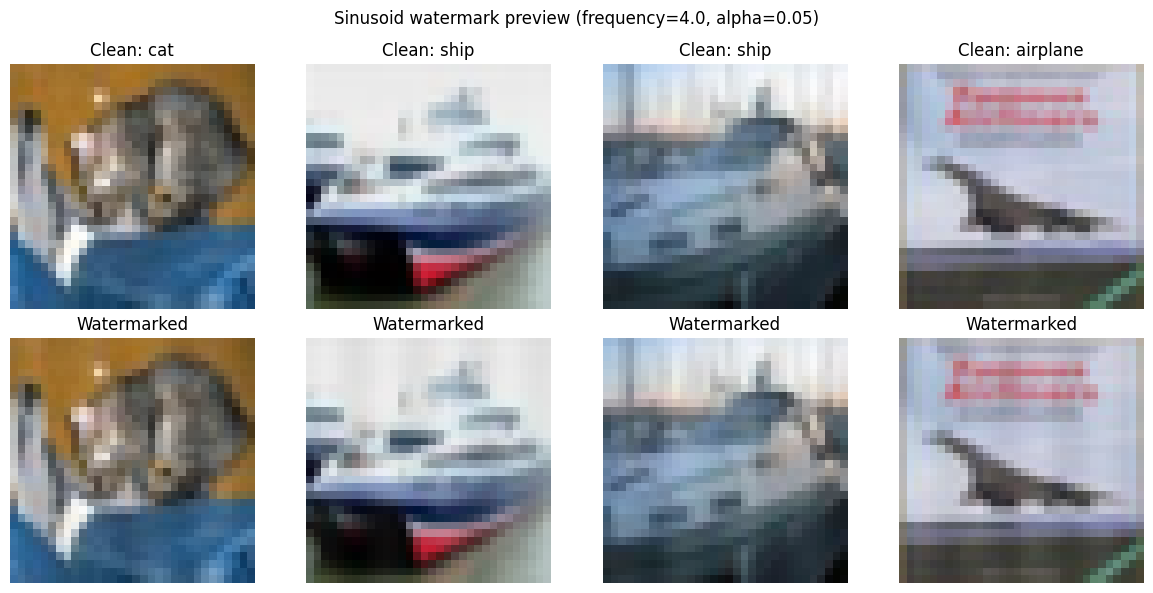

In [7]:
import matplotlib.pyplot as plt

preview_dataset = datasets.CIFAR10(root=str(data_dir), train=False, download=True)
preview_indices = [0, 1, 2, 3]
fig, axes = plt.subplots(2, len(preview_indices), figsize=(3 * len(preview_indices), 6))

for column, dataset_index in enumerate(preview_indices):
    clean_img, clean_label = preview_dataset[dataset_index]
    watermarked_img = poison_transform(clean_img.copy())
    axes[0, column].imshow(clean_img)
    axes[0, column].set_title(f"Clean: {preview_dataset.classes[clean_label]}")
    axes[1, column].imshow(watermarked_img)
    axes[1, column].set_title('Watermarked')

for ax in axes.flatten():
    ax.axis('off')

fig.suptitle(
    f"{args.watermark_type.title()} watermark preview"
    + (
        f" (frequency={args.sinusoid_frequency}, alpha={args.sinusoid_alpha})"
        if args.watermark_type == 'sinusoid'
        else ''
    )
)
plt.tight_layout()
plt.show()


Num of training samples 50000, Num of poisoned samples 5000, Num of benign samples 45000
==> Loading the model
Total params: 11.17M

Epoch: [1 | 200] LR: 0.100000


Processing: 100%|██████████| 79/79 [00:03<00:00, 23.89it/s, Epoch=Poison, Loss=1.7221, top1=21.6000, top5=99.5500]



Epoch: [2 | 200] LR: 0.100000


Processing: 100%|██████████| 79/79 [00:03<00:00, 22.38it/s, Epoch=Poison, Loss=2.1827, top1=8.8900, top5=93.5400]



Epoch: [3 | 200] LR: 0.100000


...


Epoch: [199 | 200] LR: 0.001000


Processing: 100%|██████████| 79/79 [00:04<00:00, 18.16it/s, Epoch=Poison, Loss=0.1487, top1=96.7900, top5=99.8400]



Epoch: [200 | 200] LR: 0.001000


Processing: 100%|██████████| 79/79 [00:04<00:00, 19.14it/s, Epoch=Poison, Loss=0.1560, top1=96.6300, top5=99.8600]


Best acc:
91.29


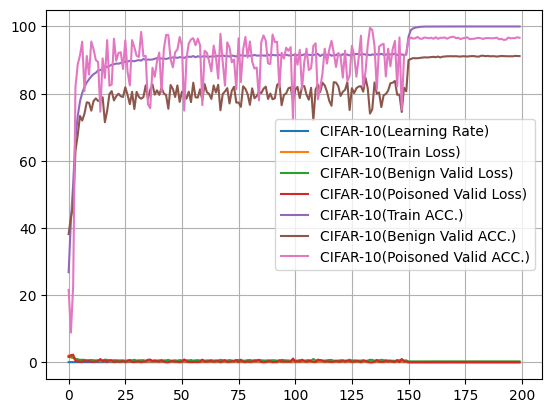

In [8]:
def train(model, poisoned_trainloader, benign_trainloader, criterion, optimizer):
    model.train()
    losses = AverageMeter(); top1 = AverageMeter(); top5 = AverageMeter(); benign_iter = iter(benign_trainloader)
    pbar = tqdm(total=len(poisoned_trainloader), desc='Processing')
    for image_poisoned, target_poisoned in poisoned_trainloader:
        try:
            image_benign, target_benign = next(benign_iter)
        except StopIteration:
            benign_iter = iter(benign_trainloader); image_benign, target_benign = next(benign_iter)
        image_poisoned, target_poisoned = image_poisoned.cuda(), target_poisoned.cuda()
        image_benign, target_benign = image_benign.cuda(), target_benign.cuda()
        image = torch.cat((image_poisoned, image_benign), 0); target = torch.cat((target_poisoned, target_benign), 0)
        outputs = model(image); loss = criterion(outputs, target)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        prec1, prec5 = accuracy(outputs.data, target.data, topk=(1, 5))
        losses.update(loss.item(), image.size(0)); top1.update(prec1.item(), image.size(0)); top5.update(prec5.item(), image.size(0))
        pbar.set_postfix({'Epoch': 'train', 'Loss': f'{losses.avg:.4f}', 'top1': f'{top1.avg:.4f}', 'top5': f'{top5.avg:.4f}'})
        pbar.update()
    pbar.close()
    return losses.avg, top1.avg


def test(testloader, model, criterion, split_name='Valid'):
    model.eval()
    losses = AverageMeter(); top1 = AverageMeter(); top5 = AverageMeter()
    pbar = tqdm(total=len(testloader), desc='Processing')
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.cuda(), targets.cuda()
            outputs = model(inputs); loss = criterion(outputs, targets)
            prec1, prec5 = accuracy(outputs.data, targets.data, topk=(1, 5))
            losses.update(loss.item(), inputs.size(0)); top1.update(prec1.item(), inputs.size(0)); top5.update(prec5.item(), inputs.size(0))
            pbar.set_postfix({'Epoch': split_name, 'Loss': f'{losses.avg:.4f}', 'top1': f'{top1.avg:.4f}', 'top5': f'{top5.avg:.4f}'})
            pbar.update()
    pbar.close()
    return losses.avg, top1.avg


def save_checkpoint(state_dict, is_best, checkpoint, filename='checkpoint.pth.tar'):
    filepath = os.path.join(checkpoint, filename)
    torch.save(state_dict, filepath)
    if is_best:
        shutil.copyfile(filepath, os.path.join(checkpoint, 'model_best.pth.tar'))


def adjust_learning_rate(optimizer, epoch):
    global state
    if epoch in args.schedule:
        state['lr'] *= args.gamma
        for param_group in optimizer.param_groups:
            param_group['lr'] = state['lr']


def main():
    global best_acc
    os.environ['CUDA_VISIBLE_DEVICES'] = args.gpu_id
    if not torch.cuda.is_available():
        raise RuntimeError('CUDA GPU not available. In Colab, go to Runtime -> Change runtime type -> T4 GPU and rerun.')
    start_epoch = args.start_epoch
    if not os.path.isdir(args.checkpoint): mkdir_p(args.checkpoint)
    transform_train_poisoned = transforms.Compose([build_watermark_transform(), transforms.RandomHorizontalFlip(), transforms.ToTensor()])
    transform_train_benign = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.ToTensor()])
    transform_test_poisoned = transforms.Compose([build_watermark_transform(), transforms.ToTensor()])
    transform_test_benign = transforms.Compose([transforms.ToTensor()])
    poisoned_trainset = datasets.CIFAR10(root=str(data_dir), train=True, download=True, transform=transform_train_poisoned)
    benign_trainset = datasets.CIFAR10(root=str(data_dir), train=True, download=True, transform=transform_train_benign)
    poisoned_testset = datasets.CIFAR10(root=str(data_dir), train=False, download=True, transform=transform_test_poisoned)
    benign_testset = datasets.CIFAR10(root=str(data_dir), train=False, download=True, transform=transform_test_benign)
    num_training = len(poisoned_trainset); num_poisoned = int(num_training * args.poison_rate)
    idx = list(np.arange(num_training)); random.shuffle(idx); poisoned_idx = idx[:num_poisoned]; benign_idx = idx[num_poisoned:]
    poisoned_trainset.data = poisoned_trainset.data[poisoned_idx, :, :, :]; poisoned_trainset.targets = [args.y_target] * num_poisoned
    benign_trainset.data = benign_trainset.data[benign_idx, :, :, :]; benign_trainset.targets = [benign_trainset.targets[i] for i in benign_idx]
    poisoned_testset.targets = [args.y_target] * len(poisoned_testset.data)
    poisoned_batch = max(1, int(args.train_batch * args.poison_rate)); benign_batch = max(1, int(args.train_batch * (1 - args.poison_rate) * 0.9))
    poisoned_trainloader = torch.utils.data.DataLoader(poisoned_trainset, batch_size=poisoned_batch, shuffle=True, num_workers=args.workers)
    benign_trainloader = torch.utils.data.DataLoader(benign_trainset, batch_size=benign_batch, shuffle=True, num_workers=args.workers)
    poisoned_testloader = torch.utils.data.DataLoader(poisoned_testset, batch_size=args.test_batch, shuffle=False, num_workers=args.workers)
    benign_testloader = torch.utils.data.DataLoader(benign_testset, batch_size=args.test_batch, shuffle=False, num_workers=args.workers)
    print('Num of training samples %i, Num of poisoned samples %i, Num of benign samples %i' % (num_training, num_poisoned, num_training - num_poisoned))
    print('==> Loading the model')
    model = ResNet18(); model = torch.nn.DataParallel(model).cuda(); cudnn.benchmark = True
    print('Total params: %.2fM' % (sum(p.numel() for p in model.parameters()) / 1000000.0))
    criterion = nn.CrossEntropyLoss(); optimizer = optim.SGD(model.parameters(), lr=args.lr, momentum=args.momentum, weight_decay=args.weight_decay)
    title = 'CIFAR-10'
    if args.resume:
        checkpoint = torch.load(args.resume); best_acc = checkpoint['best_acc']; start_epoch = checkpoint['epoch']
        model.load_state_dict(checkpoint['state_dict']); optimizer.load_state_dict(checkpoint['optimizer'])
        logger = Logger(os.path.join(args.checkpoint, 'log.txt'), title=title, resume=True)
    else:
        logger = Logger(os.path.join(args.checkpoint, 'log.txt'), title=title)
        logger.set_names(['Learning Rate', 'Train Loss', 'Benign Valid Loss', 'Poisoned Valid Loss', 'Train ACC.', 'Benign Valid ACC.', 'Poisoned Valid ACC.'])
    for epoch in range(start_epoch, args.epochs):
        adjust_learning_rate(optimizer, epoch)
        print('\nEpoch: [%d | %d] LR: %f' % (epoch + 1, args.epochs, state['lr']))
        train_loss, train_acc = train(model, poisoned_trainloader, benign_trainloader, criterion, optimizer)
        test_loss_benign, test_acc_benign = test(benign_testloader, model, criterion, split_name='Benign')
        test_loss_poisoned, test_acc_poisoned = test(poisoned_testloader, model, criterion, split_name='Poison')
        logger.append([state['lr'], train_loss, test_loss_benign, test_loss_poisoned, train_acc, test_acc_benign, test_acc_poisoned])
        is_best = test_acc_benign > best_acc; best_acc = max(test_acc_benign, best_acc)
        save_checkpoint({'epoch': epoch + 1, 'state_dict': model.state_dict(), 'acc': test_acc_benign, 'best_acc': best_acc, 'optimizer': optimizer.state_dict()}, is_best, checkpoint=args.checkpoint)
    logger.close(); logger.plot(); savefig(os.path.join(args.checkpoint, 'log.eps'))
    print('Best acc:'); print(best_acc)


main()
